<a href="https://colab.research.google.com/github/ChayananOngart/lab-ai-69/blob/main/Week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install ultralytics gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import ultralytics, torch
ultralytics.checks()
print('มีการ์ดจอให้ใช้ไหม', torch.cuda.is_available())


Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.7/107.7 GB disk)
มีการ์ดจอให้ใช้ไหม False


In [ ]:
import os, glob
ROOT = '/content/lpr'
FILE_ID = '1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt'      # รหัสของ lpr-week12-data.zip บน Google Drive ของอาจารย์
if not os.path.exists(f'{ROOT}/gate'):
    !gdown {FILE_ID} -O /content/lpr-week12-data.zip
    !unzip -q /content/lpr-week12-data.zip -d {ROOT}
for s in ['train', 'val', 'test']:
    print(f'gate/{s}', len(glob.glob(f'{ROOT}/gate/{s}/images/*')), 'ภาพ')
print('road', len(glob.glob(f'{ROOT}/road/images/*')), 'เฟรม')
print(open(f'{ROOT}/README.txt', encoding='utf-8').read())

Downloading...
From (original): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt
From (redirected): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt&confirm=t&uuid=3b03f631-3fb0-470e-b749-473966ba3270
To: /content/lpr-week12-data.zip
100% 90.8M/90.8M [00:00<00:00, 266MB/s]
gate/train 140 ภาพ
gate/val 30 ภาพ
gate/test 30 ภาพ
road 139 เฟรม
ชุดข้อมูลสำหรับใบงานแล็บสัปดาห์ที่ 12 วิชา Artificial Intelligence (520 331)
gate/  ภาพรถหน้าลานจอด 200 ใบ แบ่ง train 140 / val 30 / test 30
       ที่มา Thailand License Plates (ThailLand-plates) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
road/  เฟรมจากวิดีโอกล้องหน้ารถในกรุงเทพ 139 เฟรมที่มีเฉลย (416 ป้าย) ย่อเป็น 1920x1080
       ที่มา Thai License Plate Detector (Cytron) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
labels/ เป็นรูปแบบ YOLO (class cx cy w h หรือรูปหลายเหลี่ยม) มีคลาสเดียวคือ plate
ชื่อไฟล์ของ road มีเลขเฟรม เช่น 1_mp4-213_jpg... เลขนี้คือลำดับเวลาในวิดีโอ



In [ ]:
import yaml, random, shutil, re
from PIL import Image

def make_yaml(name, train, val, test=None):
    """เขียนไฟล์บอก YOLO ว่าชุดฝึก ชุดตรวจ ชุดสอบ อยู่โฟลเดอร์ไหน (ใช้ path เต็ม)"""
    d = {'path': ROOT, 'train': train, 'val': val, 'names': {0: 'plate'}}
    if test: d['test'] = test
    p = f'{ROOT}/{name}.yaml'
    yaml.safe_dump(d, open(p, 'w'))
    return p

def read_boxes(label_path):
    """อ่านเฉลยหนึ่งไฟล์ คืนกรอบเป็น (cx, cy, w, h) สัดส่วนของภาพ รองรับทั้งกรอบและรูปหลายเหลี่ยม"""
    boxes = []
    for line in open(label_path):
        v = list(map(float, line.split()[1:]))
        if len(v) == 4:
            boxes.append(tuple(v))
        else:
            xs, ys = v[0::2], v[1::2]
            boxes.append(((min(xs)+max(xs))/2, (min(ys)+max(ys))/2, max(xs)-min(xs), max(ys)-min(ys)))
    return boxes

def label_of(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

def link_subset(src_imgs, dst):
    """สร้างโฟลเดอร์ชุดข้อมูลใหม่จากรายชื่อภาพ โดยคัดลอกทั้งภาพและเฉลย"""
    os.makedirs(f'{dst}/images', exist_ok=True); os.makedirs(f'{dst}/labels', exist_ok=True)
    for p in src_imgs:
        shutil.copy(p, f'{dst}/images/'); shutil.copy(label_of(p), f'{dst}/labels/')
    return dst

gate_yaml = make_yaml('gate', 'gate/train/images', 'gate/val/images', 'gate/test/images')
print(open(gate_yaml).read())


names:
  0: plate
path: /content/lpr
test: gate/test/images
train: gate/train/images
val: gate/val/images



In [ ]:
from ultralytics import YOLO
from collections import Counter
coco = YOLO('yolov8n.pt')                       # สมองที่ฝึกกับ COCO มาแล้ว ดาวน์โหลดอัตโนมัติ
test_imgs = sorted(glob.glob(f'{ROOT}/gate/test/images/*'))
results = coco.predict(test_imgs, imgsz=640, conf=0.25, verbose=False)
count = Counter(coco.names[int(c)] for r in results for c in r.boxes.cls)
print('กรอบที่ตีได้ทั้งหมด', sum(count.values()))
print(count)
print('มีคำว่า license plate ในพจนานุกรม 80 คำไหม', any('plate' in n for n in coco.names.values()))

กรอบที่ตีได้ทั้งหมด 62
Counter({'car': 40, 'truck': 14, 'motorcycle': 2, 'person': 2, 'bus': 2, 'potted plant': 1, 'bicycle': 1})
มีคำว่า license plate ในพจนานุกรม 80 คำไหม False


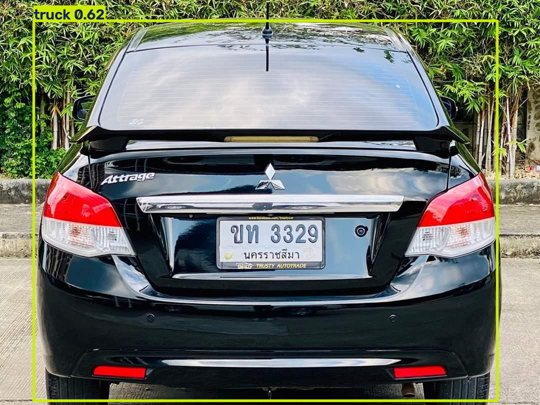

In [ ]:
from IPython.display import display
display(Image.fromarray(results[10].plot()[:, :, ::-1]).resize((540, 405)))


In [ ]:
import numpy as np
widths = []
for p in glob.glob(f'{ROOT}/gate/train/images/*'):
    for cx, cy, w, h in read_boxes(label_of(p)):
        widths.append(w)
widths = np.array(widths) * 100
print('ป้ายในชุดฝึก', len(widths), 'ใบ')
print('กว้างกลางๆ %.1f%% ของภาพ  เล็กสุด %.1f%%  ใหญ่สุด %.1f%%' % (np.median(widths), widths.min(), widths.max()))

ป้ายในชุดฝึก 141 ใบ
กว้างกลางๆ 14.3% ของภาพ  เล็กสุด 5.3%  ใหญ่สุด 25.4%


In [9]:
ft = YOLO('yolov8n.pt')
ft.train(data=gate_yaml, epochs=30, imgsz=640, batch=8, seed=0,
         project=f'{ROOT}/runs', name='finetune', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a33592427b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

รอบแรก 70  รอบที่ 7 99  รอบสุดท้าย 99.5


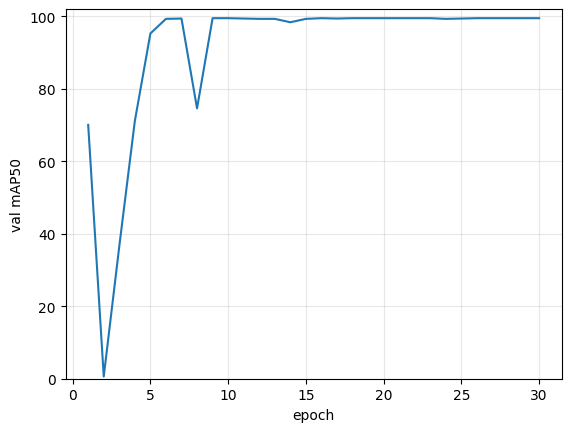

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def curve(run):
    df = pd.read_csv(f'{ROOT}/runs/{run}/results.csv')
    df.columns = [c.strip() for c in df.columns]
    return df['metrics/mAP50(B)'].values * 100

m = curve('finetune')
print('รอบแรก %.0f  รอบที่ 7 %.0f  รอบสุดท้าย %.1f' % (m[0], m[6], m[-1]))
plt.plot(range(1, len(m)+1), m); plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.show()

In [13]:
def score(weights, data, split='val'):
    r = YOLO(weights).val(data=data, split=split, imgsz=640, batch=8, plots=False, verbose=False)
    return r.box.map50 * 100, r.box.map * 100

ft_test = score(f'{ROOT}/runs/finetune/weights/best.pt', gate_yaml, 'test')
print('ชุดสอบ  mAP50 %.1f   mAP50-95 %.1f' % ft_test)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1014.3±574.1 MB/s, size: 155.4 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 6.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.0s/it 12.0s
                   all         30         30          1      0.995      0.995       0.82
Speed: 3.9ms preprocess, 340.7ms inference, 0.0ms loss, 16.2ms postprocess per image
ชุดสอบ  mAP50 99.5   mAP50-95 82.0


In [ ]:
scratch = YOLO('yolov8n.yaml')                  # โครงสร้างเดียวกัน แต่น้ำหนักเริ่มจากค่าสุ่ม
scratch.train(data=gate_yaml, epochs=30, imgsz=640, batch=8, seed=0, pretrained=False,
              project=f'{ROOT}/runs', name='scratch', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch, nbs=64, nms=None, opset=None, optimize=False, optimizer=a

In [ ]:
frozen = YOLO('yolov8n.pt')
frozen.train(data=gate_yaml, epochs=30, imgsz=640, batch=8, seed=0, freeze=10,   # ล็อก 10 ชั้นแรก คือส่วนตา
             project=f'{ROOT}/runs', name='frozen', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=frozen, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, 

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 236.5±63.9 MB/s, size: 163.7 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.9s/it 11.6s
                   all         30         30      0.959      0.933      0.983       0.65
Speed: 5.3ms preprocess, 354.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu 

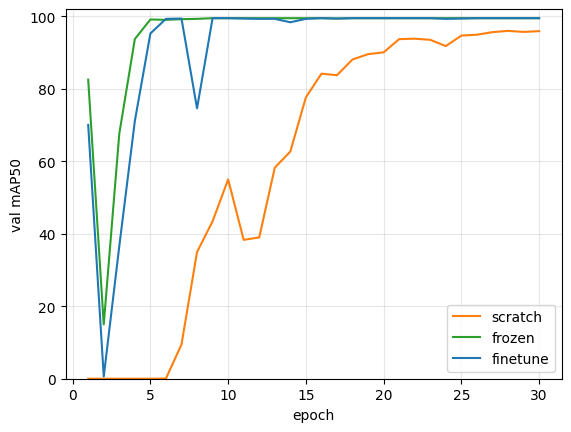

In [16]:
rows = []
for run, label in [('scratch', 'เริ่มจากศูนย์'), ('frozen', 'ยืมตาแล้วตรึง'), ('finetune', 'ยืมตาแล้วปรับทั้งตัว')]:
    m50, m5095 = score(f'{ROOT}/runs/{run}/weights/best.pt', gate_yaml, 'test')
    c = curve(run)
    stable = next((i + 1 for i in range(len(c)) if (c[i:] >= 94).all()), None)   # รอบแรกที่ยืนเหนือ 94 ได้ถาวร
    rows.append((label, c[0], '-' if stable is None else str(stable), m50, m5095))
print('%-22s %8s %12s %10s %10s' % ('วิธี', 'รอบแรก', 'ยืนเหนือ 94', 'mAP50', 'mAP50-95'))
for r in rows:
    print('%-22s %8.0f %12s %10.1f %10.1f' % r)
for run, c in [('scratch', 'tab:orange'), ('frozen', 'tab:green'), ('finetune', 'tab:blue')]:
    m = curve(run); plt.plot(range(1, len(m)+1), m, color=c, label=run)
plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.legend(); plt.show()